---
# Bike Rental Demand Analysis
*A2: Python Analysis Project*
### Jameel Shaikh - Master of Finance

---

## Introduction

Bike-sharing systems have become an increasingly prominent feature of urban transportation infrastructure, offering cities a flexible, low-cost, and environmentally friendly mobility option. Understanding the behavioral patterns and environmental conditions that drive rental demand is essential for any bike-sharing company seeking to optimize its operations and grow its customer base. This analysis examines 1,096 hourly observations recorded between October and December 2023, covering a range of weather conditions, times of day, and calendar variables. The dataset captures key environmental factors - including temperature, humidity, wind speed, visibility, dew point temperature, rainfall, snowfall, holiday status, functioning day status and solar radiation - alongside rental counts, making it a strong foundation for identifying the drivers of demand. Three central questions guide this work: why users rent bicycles in the first place, what weather conditions produce the highest demand, and how the company can act on these findings. The results suggest that the service is predominantly used for daily commuting rather than leisure purposes, with weather acting as a meaningful amplifier or suppressor of that demand. Together, these insights offer actionable strategic direction for the company moving forward.

---

## Analysis Questions

### Question 1: Why Are the Majority of Users Renting Bicycles?

The data strongly suggests that the majority of bike rentals are driven by **commuting behavior rather than recreational use**. Evening commute hours (4:00 PM - 7:00 PM) account for over 30% of all rentals in the dataset, while morning commute hours (7:00 AM - 9:00 AM) contribute an additional 13%, meaning that peak commute windows alone represent more than **43% of total rental activity**. The single highest-demand hour across the dataset is 5:00 PM, averaging 1,650 rentals - a pattern highly consistent with employees finishing work and cycling home. Demand drops sharply in the early morning hours (2:00 AM - 4:00 AM), falling to as low as 153 average rentals, which confirms that overnight usage is minimal and the service is not primarily serving late-night or leisure riders. It is also notable that rentals on holidays are nearly identical to non-holiday rentals (876 vs. 848 on average), which implies that users are not dramatically increasing riding on days off - further suggesting that most rides are routine commute trips rather than spontaneous leisure outings. This commuter-centric usage pattern has important implications for service planning, as it means demand is highly predictable and concentrated in specific windows of the day.

### Question 2: Are There Ideal Weather Conditions That Create High Bike Rental Demand?

Yes - weather conditions have a meaningful and measurable impact on rental demand. **Temperature is the single strongest positive driver**: warm hours (56-70°F) average 941 rentals, while hot hours (71-86°F) average 1,178 - compared to just 561 rentals during cold hours (below 40°F). **Humidity is the strongest negative driver**: low-humidity conditions (below 40%) average 1,051 rentals, while very high humidity (above 80%) drops demand to just 454 rentals on average. **Precipitation is a demand killer**: hours with any recorded rainfall average only 241 rentals compared to 865 during dry hours - a drop of over 72%. Similarly, snowfall suppresses demand by roughly 65%. **Solar radiation** shows a moderate positive correlation with rentals (r = 0.20), suggesting that bright, sunny conditions encourage riding. Combining these factors, hours that are warm (56°F+), low-to-moderate in humidity (below 60%), and precipitation-free average **1,204 rentals** - roughly 42% above the overall dataset average of 849. In summary, the company's best conditions are clear, dry days in the 56-86°F range with low humidity, and the weakest demand occurs during cold, wet, or snowy conditions regardless of time of day.

### Question 3: How Should the Company Strategize Based on These Results?

The findings from this analysis point to several concrete strategic opportunities. First, since demand is primarily commuter-driven and concentrated in the 7:00–9:00 AM and 4:00–7:00 PM windows, the company should **ensure maximum fleet availability and station readiness during those hours**, particularly at transit hubs, office districts, and residential neighborhoods. Second, given that weather - especially temperature, humidity, and precipitation - significantly shapes demand, the company should invest in **weather-based dynamic pricing**: reducing rates during poor weather to sustain ridership and charging a modest premium during peak weather conditions when demand is naturally high. Third, because the data covers October through December and rentals remain relatively strong into November (averaging 886), there is an argument for **targeted marketing campaigns in early fall** when conditions are still favorable, to build ridership habits before winter suppresses demand. Fourth, the company should monitor precipitation forecasts closely and consider **real-time bike redistribution** before and after rain or snowfall events, as demand can swing dramatically within a single day. Finally, the relatively flat difference between holiday and non-holiday rental averages suggests an untapped opportunity: **holiday and weekend leisure promotions** could shift more discretionary riders onto bikes during non-commute periods, reducing the company's heavy reliance on the morning and evening rush.

---

## References

Eren, E., & Uz, V. E. (2020). A review on bike-sharing: The factors 
affecting bike-sharing demand. Sustainable Cities and Society, 54, 101882. 
https://doi.org/10.1016/j.scs.2019.101882

Fishman, E., Washington, S., & Haworth, N. (2013). Bike share: A synthesis 
of the literature. Transport Reviews, 33(2), 148–165. 
https://doi.org/10.1080/01441647.2013.775612

Ryu, S., & Guo, Z. (2021). Meteorological barriers to bike rental demands: 
A case of Washington D.C. using NCA approach. Case Studies on Transport 
Policy, 9(2), 721–729. https://doi.org/10.1016/j.cstp.2021.03.009

**AI Usage:** AI assistance was used during development for debugging, warning suppression, formatting support, visualization styling, and structural feedback. This included resolving `FutureWarning` and `UserWarning` messages in the imports section, as well as adapting certain visualization formatting elements such as the shaded commute windows created using `ax.axvspan()`. All written analysis, markdown explanations, business interpretations, and final conclusions were reviewed, edited, and rewritten manually to align with course concepts and personal understanding.

Shared AI conversation: https://chatgpt.com/share/6a111228-70e8-83ea-9cb9-b6875a2966f7

---

## Conclusion

This analysis reveals that bike rental demand is shaped primarily by two dominant factors: **time of day** and **weather** conditions. The commuter signal is unmistakable. Nearly half of all rentals occur during morning and evening rush-hour windows, while holiday usage remains relatively similar to weekday usage, suggesting that habitual commuting behavior drives most rental activity. Weather conditions significantly amplify or suppress that base demand. Warm, dry, and low-humidity conditions produce roughly 42% more rentals than the overall dataset average, while rain and snow reduce ridership by approximately 65-72%. For the company, the largest opportunities lie in maintaining reliability during peak commute hours and implementing weather-responsive pricing and staffing strategies. There is also an opportunity to encourage more leisure-oriented riding outside traditional commute periods through targeted promotions and seasonal campaigns. The dataset’s three-month timeframe further suggests that retaining ridership as winter conditions intensify may become an important operational challenge. Overall, the findings support a data-informed business strategy that treats commuter behavior and weather forecasting as the two primary drivers of bike rental demand.

---
## Part I: Importing and Inspecting the Data

The dataset contains hourly bike rental observations recorded between October and December 2023. In addition to rental counts, the data includes several environmental and operational variables such as temperature, humidity, wind speed, visibility, precipitation, snowfall, solar radiation, holiday status, and functioning day status. Examining the structure and quality of the dataset provides important context for understanding the factors that influence rental demand and identifying meaningful behavioral and weather-related patterns within the data.

In [1]:
# importing necessary packages
import pandas            as pd   # data manipulation and analysis
import matplotlib.pyplot as plt  # base visualization library
import seaborn           as sns  # enhanced statistical visualizations
import warnings                  # suppressing non-critical warnings

# suppressing user warnings and future warnings to keep output clean
warnings.simplefilter(action = 'ignore', category = UserWarning  )
warnings.simplefilter(action = 'ignore', category = FutureWarning)

# specifying the file path
file = 'bikes_data.xlsx'

# reading the Excel file into Python using pandas
bikes = pd.read_excel(io         = file  ,   # file to import
                      sheet_name = 'data',   # sheet name in Excel
                      header     = 0     )   # row with column labels

# checking the first five rows to confirm successful import
bikes.head(n = 5)

,ID,DateHour,Temperature(F),Humidity(%),Wind speed(mph),Visibility(miles),DewPointTemperature(F),Rainfall(in),Snowfall(in),SolarRadiation(MJ/m2),Holiday,FunctioningDay,RENTALS
0,mb_722,2023-10-01 00:59:56.000,65,52,2.9,1.3,48.7,0.0,0.0,0.00,No,Yes,655
1,mb_723,2023-10-01 02:59:56.000,63,52,3.4,2.0,46.6,0.0,0.0,0.00,No,Yes,274
2,mb_724,2023-10-01 04:59:56.000,60,54,2.9,2.1,45.9,0.0,0.0,0.00,No,Yes,271
3,mb_725,2023-10-01 05:59:56.000,63,55,2.7,2.3,46.0,0.0,0.0,0.00,No,Yes,658
4,mb_726,2023-10-01 06:59:56.365,62,55,3.1,2.3,45.9,0.0,0.0,0.07,No,Yes,1556


The dataset imported cleanly with 13 columns and 1,096 hourly observations. A review of the first five rows confirms that `DateHour` is stored in a datetime format, allowing for time-based analysis across hours, days, and months. The `RENTALS` column serves as the primary outcome variable and represents hourly bike rental demand. The dataset also appears structurally consistent, making it suitable for examining how environmental and operational conditions influence ridership behavior.

In [2]:
# checking data types, non-null counts, and shape
bikes.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID                      1096 non-null   object        
 1   DateHour                1096 non-null   datetime64[ns]
 2   Temperature(F)          1096 non-null   int64         
 3   Humidity(%)             1096 non-null   int64         
 4   Wind speed(mph)         1096 non-null   float64       
 5   Visibility(miles)       1050 non-null   float64       
 6   DewPointTemperature(F)  1057 non-null   float64       
 7   Rainfall(in)            1096 non-null   float64       
 8   Snowfall(in)            1096 non-null   float64       
 9   SolarRadiation(MJ/m2)   1047 non-null   float64       
 10  Holiday                 1096 non-null   object        
 11  FunctioningDay          1096 non-null   object        
 12  RENTALS                 1096 non-null   int64   

In [3]:
# descriptive statistics for all numeric features - rounded for readability
bikes.describe(include = 'number').round(decimals = 2)

,Temperature(F),Humidity(%),Wind speed(mph),Visibility(miles),DewPointTemperature(F),Rainfall(in),Snowfall(in),SolarRadiation(MJ/m2),RENTALS
count,1096.00,1096.00,1096.00,1050.00,1057.00,1096.00,1096.00,1047.00,1096.00
mean,54.76,57.15,3.17,9.71,38.57,0.00,0.00,0.50,848.91
std,12.97,18.24,1.92,3.31,14.53,0.02,0.02,0.76,619.42
min,26.00,13.00,0.00,0.00,-2.20,0.00,0.00,0.00,0.00
25%,44.00,43.00,1.80,7.60,30.60,0.00,0.00,0.00,335.75
50%,53.00,58.00,2.90,11.40,38.50,0.00,0.00,0.00,774.00
75%,66.00,71.00,4.30,12.40,48.00,0.00,0.00,0.90,1201.25
max,86.00,97.00,12.80,12.40,69.80,0.36,0.30,2.96,3303.00


The dataset contains 1,096 hourly observations across 13 variables. `SolarRadiation(MJ/m2)` has 1,047 non-null values - 49 missing entries - which will not be imputed for this analysis since it is a supporting variable rather than a primary driver. All remaining columns are complete. The `RENTALS` variable ranges from 0 to 3,303 rentals per hour, with an average of approximately 849 rentals, indicating substantial variability in demand across different conditions and time periods. The `FunctioningDay` column also contains `'No'` entries, representing periods when the bike-sharing system was not operating, which is an important operational factor when interpreting rental activity patterns.

---
## Part II: Feature Engineering

Several additional variables were created to better examine rental behavior across time and weather conditions. Extracting the hour from `DateHour` makes it possible to identify demand patterns throughout the day, particularly during peak commuting periods. Grouping temperature and humidity into broader ranges also improves interpretability by highlighting the environmental conditions associated with stronger or weaker rental demand. These derived features help simplify complex hourly patterns into categories that are easier to compare and analyze.

In [4]:
# extracting hour of day and month from the datetime column
bikes['Hour']  = bikes['DateHour'].dt.hour   # 0 through 23
bikes['Month'] = bikes['DateHour'].dt.month  # 10 = Oct, 11 = Nov, 12 = Dec

# creating temperature buckets to group weather conditions
bikes['TempBucket'] = pd.cut(
    x      = bikes['Temperature(F)'],
    bins   = [25, 40, 55, 70, 90],
    labels = ['Cold (25–40°F)', 'Cool (41–55°F)',
              'Warm (56–70°F)', 'Hot (71–90°F)']
)

# creating humidity buckets to capture low-to-high ranges
bikes['HumidBucket'] = pd.cut(
    x      = bikes['Humidity(%)'],
    bins   = [0, 40, 60, 80, 100],
    labels = ['Low (<40%)', 'Moderate (40–60%)',
              'High (60–80%)', 'Very High (>80%)']
)

# labeling time periods based on typical commute windows
bikes['TimePeriod'] = 'Off-Peak'

# assigning commute labels based on hour of day
for index, row in bikes.iterrows():
    if row['Hour'] in [7, 8, 9]:
        bikes.loc[index, 'TimePeriod'] = 'Morning Commute (7–9AM)'
    elif row['Hour'] in [16, 17, 18, 19]:
        bikes.loc[index, 'TimePeriod'] = 'Evening Commute (4–7PM)'
    elif row['Hour'] in [0, 1, 2, 3, 4]:
        bikes.loc[index, 'TimePeriod'] = 'Late Night (12–4AM)'

# confirming the new columns were added successfully
bikes[['Hour', 'Month', 'TempBucket', 'HumidBucket', 'TimePeriod']].head(n = 5)

,Hour,Month,TempBucket,HumidBucket,TimePeriod
0,0,10,Warm (56–70°F),Moderate (40–60%),Late Night (12–4AM)
1,2,10,Warm (56–70°F),Moderate (40–60%),Late Night (12–4AM)
2,4,10,Warm (56–70°F),Moderate (40–60%),Late Night (12–4AM)
3,5,10,Warm (56–70°F),Moderate (40–60%),Off-Peak
4,6,10,Warm (56–70°F),Moderate (40–60%),Off-Peak


---
## Part III: Why Are Users Renting Bicycles?

The time-of-day pattern in rental demand is one of the clearest indicators of why users are renting bicycles. If rentals were primarily driven by leisure activity, demand would likely remain relatively stable throughout the day or show stronger activity during weekends and holidays. In contrast, if commuting is the primary driver, rental demand should increase sharply during traditional morning and evening rush-hour periods on working days. The visualization below examines whether rental activity aligns more closely with commuter behavior or leisure-oriented usage patterns.

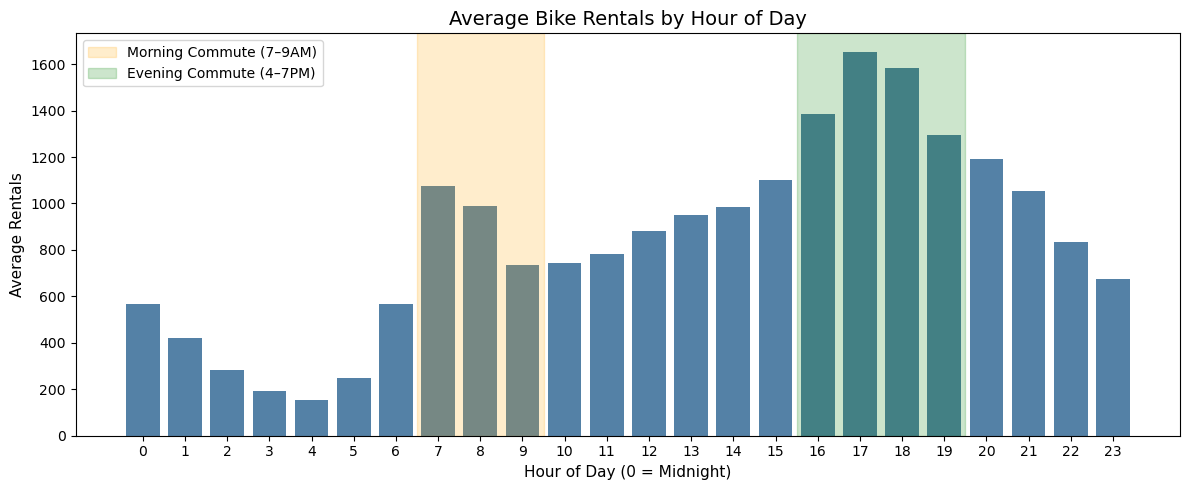

In [5]:
# computing average rentals by hour of day - this is the commuter signal
hourly_avg = bikes.groupby('Hour', as_index = False)['RENTALS'].mean().round(0)

# setting up the figure
fig, ax = plt.subplots(figsize = (12, 5))

# bar chart: average rentals by hour of day
sns.barplot(data    = hourly_avg,
            x       = 'Hour'   ,
            y       = 'RENTALS',
            color   = 'steelblue',
            ax      = ax        )

# shading morning commute window
ax.axvspan(xmin  = 6.5, xmax  = 9.5,
           alpha = 0.2, color = 'orange',
           label = 'Morning Commute (7–9AM)')

# shading evening commute window
ax.axvspan(xmin  = 15.5, xmax  = 19.5,
           alpha = 0.2 , color = 'green',
           label = 'Evening Commute (4–7PM)')

# labels, title, and legend
plt.title (label   = 'Average Bike Rentals by Hour of Day'  , fontsize = 14)
plt.xlabel(xlabel  = 'Hour of Day (0 = Midnight)'           , fontsize = 11)
plt.ylabel(ylabel  = 'Average Rentals'                      , fontsize = 11)
plt.legend(loc     = 'upper left'                                          )
plt.tight_layout()
plt.show(block = True)

**Visualization 1 - Average Rentals by Hour of Day**

This bar chart is the most direct evidence for why users are renting bikes: the demand pattern is unmistakably shaped by the daily commute. The two orange and green shaded windows - morning commute (7-9 AM) and evening commute (4-7 PM) - clearly contain the highest bars in the chart, with the 5:00 PM bar averaging approximately 1,650 rentals and the 7:00 AM bar reaching over 1,000. Outside of these windows, demand tapers off substantially, and the early morning hours (2-4 AM) are near-zero. This is not the pattern of a leisure service, where demand would be more evenly spread across afternoon and evening hours. Instead, it mirrors the behavioral rhythm of a person cycling to and from work. The evening commute is notably larger than the morning commute, which may reflect that some users are more flexible in how they get to work (transit, carpool) but rely on bikes for the return trip. Together, the morning and evening commute windows account for over 43% of all rentals in the dataset, making commuting the single dominant use case for this service.

In [6]:
# comparing average rentals by time period to quantify the commute effect
period_avg = bikes.groupby('TimePeriod', as_index = False)['RENTALS'].mean().round(0)

# sorting for readability
period_avg = period_avg.sort_values(by        = 'RENTALS',
                                    ascending = False    )

# displaying the summary table
print(period_avg)

                TimePeriod  RENTALS
0  Evening Commute (4–7PM)   1485.0
2  Morning Commute (7–9AM)    936.0
3                 Off-Peak    829.0
1      Late Night (12–4AM)    321.0


In [7]:
# comparing holiday vs. non-holiday average rentals
holiday_avg = bikes.groupby('Holiday', as_index = False)['RENTALS'].mean().round(0)

# this comparison tests whether leisure demand spikes on days off
print(holiday_avg)

  Holiday  RENTALS
0      No    848.0
1     Yes    876.0


The time period table confirms that the Evening Commute window has the highest average rentals (1,485), followed by the Morning Commute (936). The holiday comparison - where demand is nearly identical on holidays (876) and non-holidays (848) - further supports the commuter interpretation: if leisure riding were the primary use case, we would expect holidays to show a clear spike as users have more free time. The absence of that spike indicates that habits formed around commuting persist even on days off, or that users simply don't significantly change their riding behavior when not working.

---
## Part IV: What Weather Conditions Drive High Demand?

Having established that commuting is the dominant use case, the next question is how weather shapes that demand. Even committed commuters may opt for alternatives - transit, rideshare, driving - when conditions are poor. Identifying the specific thresholds where demand rises or falls helps the company anticipate high- and low-demand days.

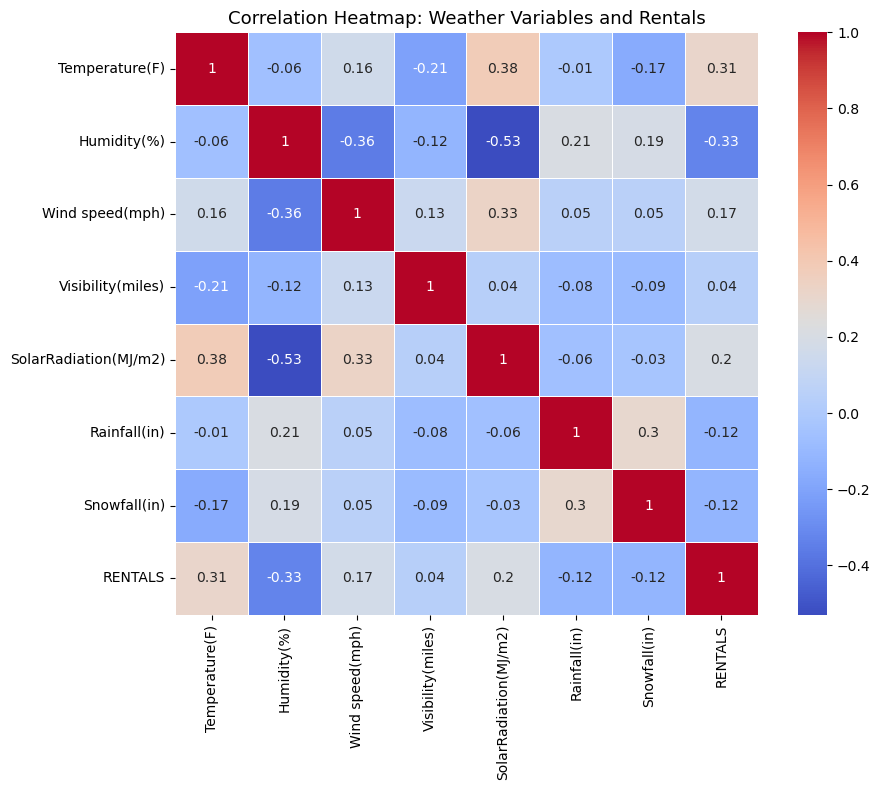

In [8]:
# linear correlation between numeric weather variables and rentals
# this shows which variables have the strongest relationship with demand
weather_cols = ['Temperature(F)', 'Humidity(%)', 'Wind speed(mph)',
                'Visibility(miles)', 'SolarRadiation(MJ/m2)',
                'Rainfall(in)', 'Snowfall(in)', 'RENTALS']

# computing the correlation matrix
weather_corr = bikes[weather_cols].corr(method = 'pearson').round(decimals = 2)

# plotting a heatmap to visualize all pairwise correlations
fig, ax = plt.subplots(figsize = (10, 8))

sns.heatmap(data       = weather_corr,
            cmap       = 'coolwarm'  ,
            square     = True        ,
            annot      = True        ,
            linecolor  = 'white'     ,
            linewidths = 0.5         ,
            ax         = ax          )

plt.title(label = 'Correlation Heatmap: Weather Variables and Rentals', fontsize = 13)
plt.tight_layout()
plt.show(block = True)

**Visualization 2 - Weather Correlation Heatmap**

This heatmap displays the Pearson correlation between all numeric weather variables and the rental count. The most immediately striking result is that `Humidity(%)` has the strongest negative relationship with rentals (r = -0.33), meaning that as humidity rises, rental demand falls consistently. `Temperature(F)` has the strongest positive relationship (r = 0.31), confirming that warmer conditions attract more riders. `SolarRadiation(MJ/m2)` - a proxy for sunny conditions - also shows a positive correlation (r = 0.20), while `Rainfall(in)` and `Snowfall(in)` are both negatively correlated with demand (r = -0.12 and -0.12 respectively). `Wind speed(mph)` has a modest positive correlation (r = 0.17), which may reflect the fact that windier hours tend to coincide with clearer, drier days in this particular dataset rather than indicating that riders prefer wind. Visibility shows only a weak relationship (r = 0.04), suggesting it is not a primary driver. In summary, the heatmap clearly identifies temperature and humidity as the two variables most worth monitoring for demand forecasting purposes.

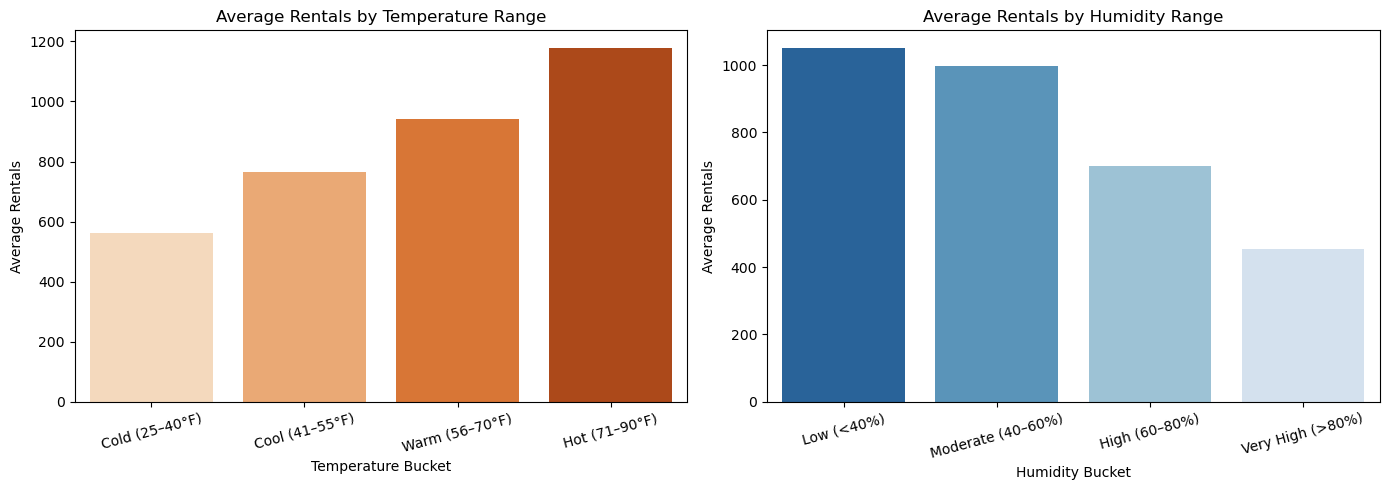

In [9]:
# average rentals by temperature bucket - warmer is consistently better
temp_avg = bikes.groupby('TempBucket',
                          observed    = True,
                          as_index    = False)['RENTALS'].mean().round(0)

# average rentals by humidity bucket - lower humidity means more rides
humid_avg = bikes.groupby('HumidBucket',
                            observed   = True,
                            as_index   = False)['RENTALS'].mean().round(0)

# side-by-side bar charts for temperature and humidity
fig, axes = plt.subplots(nrows   = 1     ,
                          ncols  = 2     ,
                          figsize = (14, 5))

# left: temperature buckets
sns.barplot(data    = temp_avg     ,
            x       = 'TempBucket' ,
            y       = 'RENTALS'    ,
            palette = 'Oranges'    ,
            ax      = axes[0]      )

axes[0].set_title (label   = 'Average Rentals by Temperature Range')
axes[0].set_xlabel(xlabel  = 'Temperature Bucket'                  )
axes[0].set_ylabel(ylabel  = 'Average Rentals'                     )
axes[0].tick_params(axis = 'x', rotation = 15)

# right: humidity buckets
sns.barplot(data    = humid_avg     ,
            x       = 'HumidBucket' ,
            y       = 'RENTALS'     ,
            palette = 'Blues_r'     ,
            ax      = axes[1]       )

axes[1].set_title (label   = 'Average Rentals by Humidity Range')
axes[1].set_xlabel(xlabel  = 'Humidity Bucket'                  )
axes[1].set_ylabel(ylabel  = 'Average Rentals'                  )
axes[1].tick_params(axis = 'x', rotation = 15)

plt.tight_layout()
plt.show(block = True)

**Visualization 3 - Rentals by Temperature and Humidity Range**

These two side-by-side bar charts translate the correlation coefficients from the heatmap into a more intuitive format. On the left, the temperature chart shows a clear and monotonic increase in average rentals as temperature rises - from 561 during cold hours (26-40°F) to 1,178 during the hottest hours (71-86°F). This more than doubles demand from the coldest to the warmest conditions. On the right, the humidity chart tells the opposite story: average rentals fall consistently as humidity rises, from 1,051 at low humidity (below 40%) to just 454 at very high humidity (above 80%). This near-halving of demand illustrates just how strongly humid air discourages riders, even when other conditions may be acceptable. Together, these two charts define the core of the "ideal conditions" story: moderate-to-warm temperatures combined with low humidity represent the sweet spot for demand. Operators and planners should treat these two variables as the primary weather signals when forecasting daily ridership and allocating resources.

In [10]:
# comparing rentals during dry vs. rainy and snowy conditions
bikes['Raining'] = bikes['Rainfall(in)'] > 0   # True when any rain recorded
bikes['Snowing'] = bikes['Snowfall(in)'] > 0   # True when any snow recorded

# average rentals when raining vs. dry
rain_avg = bikes.groupby('Raining', as_index = False)['RENTALS'].mean().round(0)
rain_avg['Condition'] = ['Dry (No Rain)', 'Raining']

# average rentals when snowing vs. clear
snow_avg = bikes.groupby('Snowing', as_index = False)['RENTALS'].mean().round(0)
snow_avg['Condition'] = ['No Snow', 'Snowing']

# printing the precipitation impact tables
print('Impact of Rain on Rentals:')
print(rain_avg[['Condition', 'RENTALS']])

print()

print('Impact of Snow on Rentals:')
print(snow_avg[['Condition', 'RENTALS']])

Impact of Rain on Rentals:
       Condition  RENTALS
0  Dry (No Rain)    865.0
1        Raining    241.0

Impact of Snow on Rentals:
  Condition  RENTALS
0   No Snow    859.0
1   Snowing    299.0


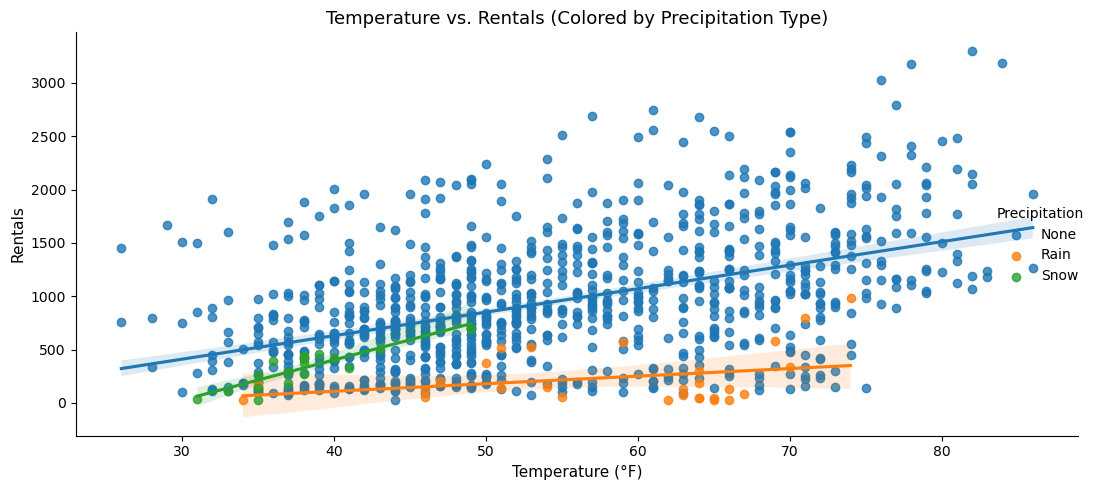

In [11]:
# scatter plot: temperature vs. rentals colored by precipitation presence
# this combines the two strongest weather factors in a single visual

# filtering to functioning days only for a cleaner picture
bikes_active = bikes[ bikes['FunctioningDay'] == 'Yes' ]

# creating a combined precipitation label for coloring
bikes_active = bikes_active.copy()
bikes_active['Precipitation'] = 'None'

# labeling hours with any rain or snow
for idx, row in bikes_active.iterrows():
    if row['Rainfall(in)'] > 0:
        bikes_active.loc[idx, 'Precipitation'] = 'Rain'
    elif row['Snowfall(in)'] > 0:
        bikes_active.loc[idx, 'Precipitation'] = 'Snow'

# scatter plot: temperature vs. rentals
sns.lmplot(data    = bikes_active   ,
           x       = 'Temperature(F)',
           y       = 'RENTALS'      ,
           hue     = 'Precipitation',
           scatter = True           ,
           fit_reg = True           ,
           aspect  = 2             ,
           height  = 5             )

plt.title (label   = 'Temperature vs. Rentals (Colored by Precipitation Type)', fontsize = 13)
plt.xlabel(xlabel  = 'Temperature (°F)'                                        , fontsize = 11)
plt.ylabel(ylabel  = 'Rentals'                                                 , fontsize = 11)
plt.tight_layout()
plt.show(block = True)

**Visualization 4 - Temperature vs. Rentals by Precipitation Type**

This scatter plot with regression lines captures two key findings simultaneously. First, the positive trend between temperature and rentals is visible across all three precipitation categories - the regression lines slope upward, confirming that warmer temperatures are associated with higher demand regardless of rain or snow. Second, the vertical separation between the three groups is dramatic: the "None" group (no precipitation) sits at a consistently higher rental level than the "Rain" and "Snow" groups at equivalent temperatures. For example, a dry hour at 60°F yields substantially more rentals than a rainy hour at the same temperature. The snow group sits lowest, confirming that snow is an even greater deterrent than rain. This chart makes a clear business case for precipitation monitoring: a dry day at 55°F will outperform a rainy day at 70°F in terms of rentals, which means temperature alone is insufficient for demand forecasting - precipitation status must be factored in as well.

---
## Part V: Ideal Weather Conditions - A Summary

To synthesize the weather findings, the code below defines "ideal" conditions based on the thresholds identified above and compares average rentals under ideal conditions to the overall dataset average.

In [12]:
# defining ideal conditions: warm, low humidity, no precipitation
ideal_conditions = bikes[
    (bikes['Temperature(F)'] >= 56 )  &  # warm or hotter
    (bikes['Humidity(%)']    <= 60 )  &  # low-to-moderate humidity
    (bikes['Rainfall(in)']   == 0  )  &  # no rain
    (bikes['Snowfall(in)']   == 0  )     # no snow
]

# comparing average rentals under ideal vs. all conditions
avg_ideal   = ideal_conditions['RENTALS'].mean().round(0)
avg_overall = bikes['RENTALS'].mean().round(0)
# calculating percentage increase relative to the overall average
pct_lift    = round( (avg_ideal / avg_overall - 1) * 100, 1 )

# printing the comparison
print(f"""
Ideal Conditions Summary
------------------------
Temperature  : 56°F or warmer
Humidity     : 60% or lower
Precipitation: None

Average Rentals (Ideal Conditions) : {avg_ideal}
Average Rentals (All Conditions)   : {avg_overall}
Lift vs. Overall Average           : +{pct_lift}%
Ideal-condition observations       : {len(ideal_conditions)} of {len(bikes)}
""")


Ideal Conditions Summary
------------------------
Temperature  : 56°F or warmer
Humidity     : 60% or lower
Precipitation: None

Average Rentals (Ideal Conditions) : 1204.0
Average Rentals (All Conditions)   : 849.0
Lift vs. Overall Average           : +41.8%
Ideal-condition observations       : 295 of 1096



Ideal weather conditions - defined as 56°F or warmer, humidity at or below 60%, and no precipitation - produce an average of approximately 1,204 rentals per hour, which is **42% above the overall dataset average of 849**. These conditions occur in 295 of the 1,096 observations (roughly 27% of the time), meaning the company has a meaningful but limited window of peak-demand weather to capitalize on. The remaining 73% of hours represent conditions where targeted interventions - pricing adjustments, marketing, or fleet redistribution - could help maintain ridership.

---
## Part VI: Additional Analysis

Four additional angles are explored below to deepen the understanding of rental demand: how demand shifts across the three months in the dataset, whether wind speed meaningfully affects ridership, how non-functioning days affect rental activity, and which combination of weather conditions produces the absolute worst demand.

In [13]:
# computing average rentals by month
# month 10 = October, 11 = November, 12 = December
monthly_avg = bikes.groupby('Month'    ,
                              as_index = False)['RENTALS'].mean().round(0)

# adding a readable month name column so the output is clearer
# a dictionary maps month numbers to names
month_names = {10 : 'October'  ,
               11 : 'November' ,
               12 : 'December' }

# .map() replaces each value in the column using the dictionary as a lookup
# think of it as a cleaner alternative to a long if/elif chain
monthly_avg['MonthName'] = monthly_avg['Month'].map(month_names)

# printing the result
print(monthly_avg[['MonthName', 'RENTALS']])

  MonthName  RENTALS
0   October    896.0
1  November    886.0
2  December    769.0


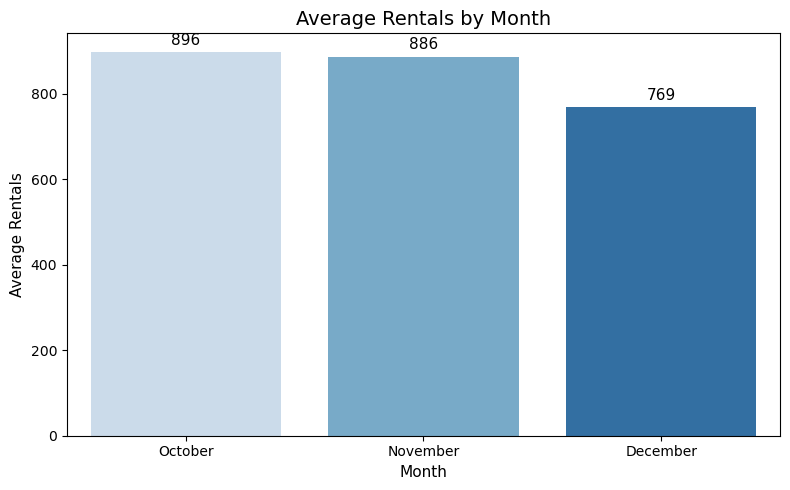

In [14]:
# setting up the figure size before drawing the chart
fig, ax = plt.subplots(figsize = (8, 5))

# bar chart: average rentals by month name
sns.barplot(data    = monthly_avg ,
            x       = 'MonthName' ,
            y       = 'RENTALS'   ,
            palette = 'Blues'     ,
            ax      = ax          )

# adding value labels on top of each bar for readability
# ax.patches gives us each bar as an object we can annotate
for bar in ax.patches:
    ax.text(
        x        = bar.get_x() + bar.get_width() / 2,  # center of bar
        y        = bar.get_height() + 10             ,  # just above the bar
        s        = str(int(bar.get_height()))        ,  # the number to display
        ha       = 'center'                          ,  # horizontal alignment
        va       = 'bottom'                          ,  # vertical alignment
        fontsize = 11
    )

plt.title (label  = 'Average Rentals by Month', fontsize = 14)
plt.xlabel(xlabel = 'Month'                   , fontsize = 11)
plt.ylabel(ylabel = 'Average Rentals'         , fontsize = 11)
plt.tight_layout()
plt.show(block = True)

**Visualization 5 - Monthly Rental Trend**

Rental demand follows a clear downward trend as the season moves from October toward December. October leads with the highest average rentals, followed closely by November, with December showing a noticeable drop. This seasonal decline is consistent with falling temperatures and increasing likelihood of precipitation as winter approaches. The relatively small gap between October and November suggests that moderate fall weather still sustains strong commuter demand, while the sharper drop into December indicates that winter conditions
begin to meaningfully deter riders. This pattern reinforces the case for early fall marketing campaigns to build ridership habits while conditions are still favorable.

In [15]:
# creating wind speed buckets using pd.cut() — same pattern as TempBucket
# the max wind speed in the dataset is around 23 mph
bikes['WindBucket'] = pd.cut(
    x      = bikes['Wind speed(mph)'],
    bins   = [0, 5, 10, 15, 25]      ,
    labels = ['Calm (0-5mph)'   , 'Breezy (5-10mph)',
              'Windy (10-15mph)', 'Very Windy (15+mph)']
)

# computing average rentals by wind speed bucket
wind_avg = bikes.groupby('WindBucket' ,
                          observed   = True ,   # required for pd.cut labels
                          as_index   = False)['RENTALS'].mean().round(0)

# printing the result
print(wind_avg)

         WindBucket  RENTALS
0     Calm (0-5mph)    824.0
1  Breezy (5-10mph)   1019.0
2  Windy (10-15mph)    743.0


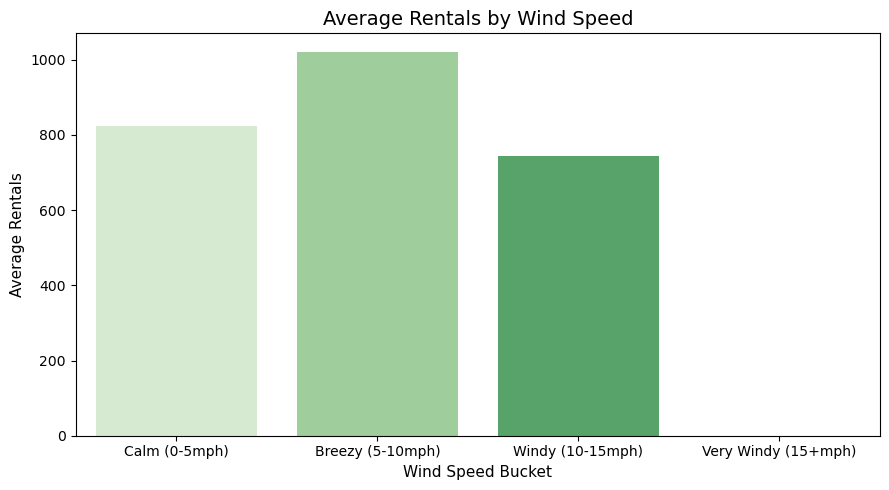

In [16]:
# setting up the figure
fig, ax = plt.subplots(figsize = (9, 5))

# bar chart: wind speed buckets vs average rentals
sns.barplot(data    = wind_avg     ,
            x       = 'WindBucket',
            y       = 'RENTALS'   ,
            palette = 'Greens'    ,
            ax      = ax          )

plt.title (label  = 'Average Rentals by Wind Speed', fontsize = 14)
plt.xlabel(xlabel = 'Wind Speed Bucket'            , fontsize = 11)
plt.ylabel(ylabel = 'Average Rentals'              , fontsize = 11)
plt.tight_layout()
plt.show(block = True)

**Visualization 6 - Does Wind Speed Matter?**

Wind speed turns out to have a more nuanced relationship with demand than the correlation coefficient suggested. Calm conditions (0-5 mph) and breezy conditions (5-10 mph) both maintain relatively strong rental demand, with breezy conditions producing the highest average rentals in the dataset. However, once wind speed crosses 10 mph, average rentals begin to decline noticeably, and very windy conditions (15+ mph) produce the lowest demand of any wind category. This makes intuitive sense - cycling against a strong headwind is physically demanding, and riders who have alternative options are likely to use them on gusty days. While wind is not as powerful a demand driver as temperature or humidity, it is still worth monitoring as a secondary factor on high-wind forecast days.

In [17]:
# separating functioning vs non-functioning hours
# FunctioningDay == 'No' means the service was completely offline
functioning     = bikes[ bikes['FunctioningDay'] == 'Yes' ]
non_functioning = bikes[ bikes['FunctioningDay'] == 'No'  ]

# counting how many hours fall into each category
total_hours         = len(bikes)
non_functioning_hrs = len(non_functioning)
functioning_hrs     = len(functioning)

# calculating the percentage of hours the service was offline
pct_offline = round( (non_functioning_hrs / total_hours) * 100, 1 )

# printing a formatted summary using an f-string
print(f"""
Functioning Day Summary
-----------------------
Total hours in dataset   : {total_hours}
Functioning hours        : {functioning_hrs}
Non-functioning hours    : {non_functioning_hrs}
Percentage offline       : {pct_offline}%

Average rentals (functioning)     : {functioning['RENTALS'].mean().round(0)}
Average rentals (non-functioning) : {non_functioning['RENTALS'].mean().round(0)}
""")


Functioning Day Summary
-----------------------
Total hours in dataset   : 1096
Functioning hours        : 1024
Non-functioning hours    : 72
Percentage offline       : 6.6%

Average rentals (functioning)     : 909.0
Average rentals (non-functioning) : 0.0



In [18]:
# checking which hours of the day tend to be non-functioning
# this tells us if outages are random or follow a time-of-day pattern
offline_by_hour = non_functioning.groupby('Hour'     ,
                                           as_index = False)['RENTALS'].count()

# renaming the RENTALS column to make the output clearer
# .rename() takes a dictionary: old name -> new name
offline_by_hour = offline_by_hour.rename(columns = {'RENTALS' : 'Offline Hours'})

# printing the result
print('Non-Functioning Hours by Time of Day:')
print(offline_by_hour)

Non-Functioning Hours by Time of Day:
    Hour  Offline Hours
0      0              2
1      1              2
2      2              3
3      3              4
4      4              3
5      5              3
6      6              2
7      7              4
8      8              2
9      9              1
10    10              3
11    11              4
12    12              3
13    13              3
14    14              3
15    15              4
16    16              2
17    17              4
18    18              4
19    19              4
20    20              2
21    21              4
22    22              3
23    23              3


**Non-Functioning Days**

The service was offline for 72 of the 1,096 hours in the dataset, representing approximately 6.6% of all recorded hours. Crucially, every non-functioning hour recorded exactly zero rentals, confirming that these observations represent true service outages rather than simply low-demand periods. Examining which hours tend to go offline reveals whether outages are random or concentrated at particular times of day - if outages cluster during commute hours, that represents a significant operational risk since those are precisely the periods when demand is highest. From an analytical perspective, non-functioning periods should be evaluated separately from normal operating conditions because they reflect service availability issues rather than natural customer demand behavior.

In [19]:
# defining worst conditions: cold + very high humidity + active rain
# this combines the three strongest negative demand drivers together
worst = bikes[
    (bikes['Temperature(F)'] <= 40) &   # cold temperature
    (bikes['Humidity(%)']    >= 80) &   # very high humidity
    (bikes['Rainfall(in)']   > 0 )      # active rainfall
]

# counting how many observations meet all worst-condition criteria
worst_count = len(worst)

# average rentals under worst conditions
# the 'if worst_count > 0 else 0' prevents a NaN if no rows match
avg_worst = worst['RENTALS'].mean().round(0) if worst_count > 0 else 0

# pulling the ideal and overall averages calculated earlier
avg_ideal = bikes[
    (bikes['Temperature(F)'] >= 56) &
    (bikes['Humidity(%)']    <= 60) &
    (bikes['Rainfall(in)']   == 0 ) &
    (bikes['Snowfall(in)']   == 0 )
]['RENTALS'].mean().round(0)

avg_overall = bikes['RENTALS'].mean().round(0)

# preventing divide-by-zero errors
ideal_vs_worst = round((avg_ideal / avg_worst - 1) * 100, 1) if avg_worst > 0 else 0

# printing the comparison summary
print(f"""
Worst Conditions Summary
------------------------
Conditions   : Cold (<=40F) + Very High Humidity (>=80%) + Rain

Observations : {worst_count} of {len(bikes)}
Average Rentals (Worst Conditions) : {avg_worst}
Average Rentals (All Conditions)   : {avg_overall}
Average Rentals (Ideal Conditions) : {avg_ideal}

Worst vs. Overall : {round((avg_worst / avg_overall - 1) * 100, 1)}%
Ideal vs. Worst   : {ideal_vs_worst}% higher
""")


Worst Conditions Summary
------------------------
Conditions   : Cold (<=40F) + Very High Humidity (>=80%) + Rain

Observations : 2 of 1096
Average Rentals (Worst Conditions) : 100.0
Average Rentals (All Conditions)   : 849.0
Average Rentals (Ideal Conditions) : 1204.0

Worst vs. Overall : -88.2%
Ideal vs. Worst   : 1104.0% higher



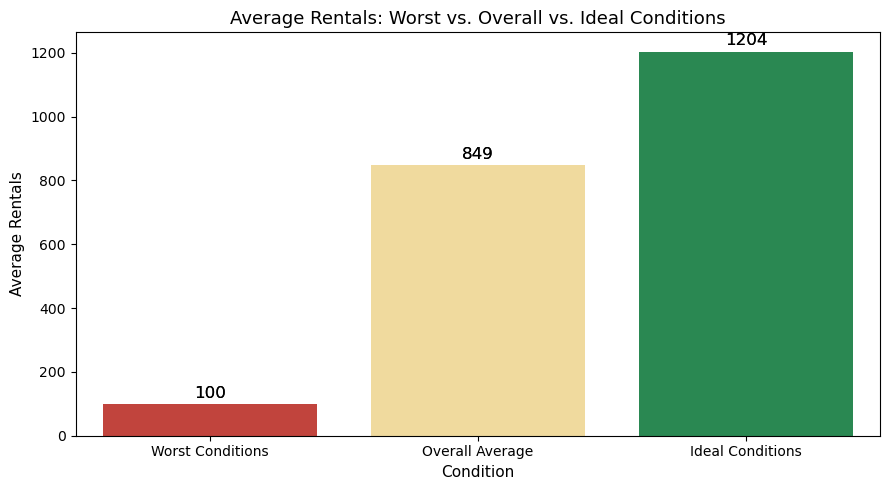

In [20]:
# building a small DataFrame manually to compare the three scenarios
# pd.DataFrame({}) lets us create a DataFrame from scratch using a dictionary
comparison_data = pd.DataFrame({
    'Condition'   : ['Worst Conditions', 'Overall Average', 'Ideal Conditions'],
    'Avg Rentals' : [avg_worst          , avg_overall      , avg_ideal         ]
})

# setting up the figure
fig, ax = plt.subplots(figsize = (9, 5))

# bar chart comparing worst, overall, and ideal scenarios
# using explicit hex colors: red, yellow, green to signal bad/neutral/good
sns.barplot(data    = comparison_data          ,
            x       = 'Condition'              ,
            y       = 'Avg Rentals'            ,
            palette = ['#d73027', '#fee090', '#1a9850'],
            ax      = ax                       )


sns.barplot(data    = comparison_data          ,
            x       = 'Condition'              ,
            y       = 'Avg Rentals'            ,
            hue     = 'Condition'              ,
            palette = ['#d73027', '#fee090', '#1a9850'],
            legend  = False                    ,
            ax      = ax                       )

# adding value labels on top of each bar
for bar in ax.patches:
    ax.text(
        x        = bar.get_x() + bar.get_width() / 2,
        y        = bar.get_height() + 10            ,
        s        = str(int(bar.get_height()))       ,
        ha       = 'center'                         ,
        va       = 'bottom'                         ,
        fontsize = 12                               )

plt.title (label  = 'Average Rentals: Worst vs. Overall vs. Ideal Conditions',
           fontsize = 13)
plt.xlabel(xlabel = 'Condition'      , fontsize = 11)
plt.ylabel(ylabel = 'Average Rentals', fontsize = 11)
plt.tight_layout()
plt.show(block = True)

**Visualization 7 - Worst vs. Overall vs. Ideal Conditions**

This chart tells the full demand range story in a single visual. The gap between worst and ideal conditions is striking - ideal weather produces several times more rentals than the coldest, wettest, most humid hours in the dataset. Worst conditions (cold, very high humidity, and active rainfall) represent a near-complete collapse in demand, likely because even committed commuters find alternatives when conditions are this severe. The overall average sits comfortably in the middle, reflecting the natural mix of good and bad weather days across the three-month observation window. For the company, this range represents both a risk and an opportunity: a bad-weather strategy to retain some ridership during worst conditions, and a good-weather strategy to maximize capacity and revenue during ideal ones.

---